## Importing Libraries and Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
data = pd.read_csv('bank-marketing-cleaned.csv',usecols=['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'campaign', 'pdays', 'previous'])

data.head()

y=pd.read_csv('outcome.csv')

In [4]:

print(data.info())

print(data.describe())

# Checking for missing values
print(data.isnull().sum())

# Check uniques for categorical columns
print(data.select_dtypes(include='object').nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   campaign   45211 non-null  int64 
 10  pdays      45211 non-null  int64 
 11  previous   45211 non-null  int64 
dtypes: int64(5), object(7)
memory usage: 4.1+ MB
None
                age        balance      campaign         pdays      previous
count  45211.000000   45211.000000  45211.000000  45211.000000  45211.000000
mean      40.936210    1362.272058      2.763841     40.197828      0.580323
std       10.618762    3044.765829      3.098021    100.128

In [5]:
print(data.isnull().sum())

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
campaign     0
pdays        0
previous     0
dtype: int64


In [6]:
categorical_columns = data.select_dtypes(include='object').columns
for column in categorical_columns:
    print(f"Unique values in {column}:")
    print(data[column].value_counts())

Unique values in job:
job
blue-collar      10020
management        9458
technician        7597
admin.            5171
services          4154
retired           2264
self-employed     1579
entrepreneur      1487
unemployed        1303
housemaid         1240
student            938
Name: count, dtype: int64
Unique values in marital:
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64
Unique values in education:
education
secondary    25059
tertiary     13301
primary       6851
Name: count, dtype: int64
Unique values in default:
default
no     44396
yes      815
Name: count, dtype: int64
Unique values in housing:
housing
yes    25130
no     20081
Name: count, dtype: int64
Unique values in loan:
loan
no     37967
yes     7244
Name: count, dtype: int64
Unique values in contact:
contact
cellular     29285
secondary    13020
telephone     2906
Name: count, dtype: int64


## Exploratory Data Analysis

In [7]:
y.drop(columns='Unnamed: 0',axis=1,inplace=True)

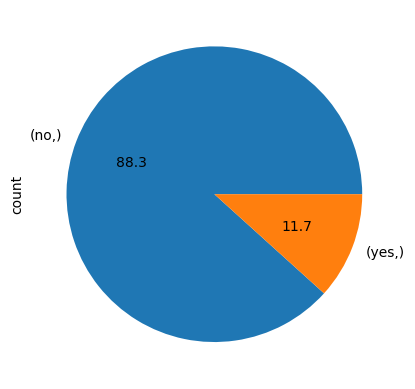

In [8]:
y.value_counts().plot(kind='pie',autopct='%1.1f')
plt.show()

## Feature Engineering

In [9]:
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,campaign,pdays,previous
0,58,management,married,tertiary,no,2143,yes,no,secondary,1,-1,0
1,44,technician,single,secondary,no,29,yes,no,secondary,1,-1,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,secondary,1,-1,0
3,47,blue-collar,married,secondary,no,1506,yes,no,secondary,1,-1,0
4,33,blue-collar,single,secondary,no,1,no,no,secondary,1,-1,0


In [10]:
print(data['education'].value_counts()) #ordinal
print(data['marital'].value_counts()) #ohe
print(data['contact'].value_counts()) #ohe
print(data['job'].value_counts()) #ohe
print(data['default'].value_counts()) #ohe
print(data['housing'].value_counts()) #ohe
print(data['loan'].value_counts()) #ohe

education
secondary    25059
tertiary     13301
primary       6851
Name: count, dtype: int64
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64
contact
cellular     29285
secondary    13020
telephone     2906
Name: count, dtype: int64
job
blue-collar      10020
management        9458
technician        7597
admin.            5171
services          4154
retired           2264
self-employed     1579
entrepreneur      1487
unemployed        1303
housemaid         1240
student            938
Name: count, dtype: int64
default
no     44396
yes      815
Name: count, dtype: int64
housing
yes    25130
no     20081
Name: count, dtype: int64
loan
no     37967
yes     7244
Name: count, dtype: int64


In [11]:
X_train,X_test,y_train,y_test=train_test_split(data,y,test_size=0.25,random_state=42)

In [12]:
transformer = ColumnTransformer(transformers=[
    ('ohe',OneHotEncoder(),['job','marital','default','housing','loan','contact']),
    ('ord',OrdinalEncoder(),['education'])],
                                remainder='passthrough')
scaler =ColumnTransformer(transformers=[
    (('stdsc',StandardScaler(),slice(0,11)))
])

In [13]:
transformer
scaler

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('stdsc', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_

## Model Building & Selection

### Logistic Regression

In [14]:
# after randomized search cv
log_trf = LogisticRegression(solver='saga',penalty='l1',
                             C=0.001,max_iter=500)
pipe = Pipeline([
    ('trf1',transformer), #encoding
    ('trf2',scaler),  #feature scaling
    ('smote',SMOTE(random_state=42)), # handle class imbalance
    ('log_trf',log_trf) # model
    ])

In [15]:
pipe.fit(X_train,y_train)

d:\Bank-Marketing-Term-Predict\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Bank-Marketing-Term-Predict\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
d:\Bank-Marketing-Term-Predict\venv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,steps,"[('trf1', ...), ('trf2', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ohe', ...), ('ord', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The g

In [16]:
y_pred =pipe.predict(X_test)

In [17]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

          no       0.90      0.70      0.79      9950
         yes       0.17      0.45      0.25      1353

    accuracy                           0.67     11303
   macro avg       0.54      0.57      0.52     11303
weighted avg       0.82      0.67      0.72     11303



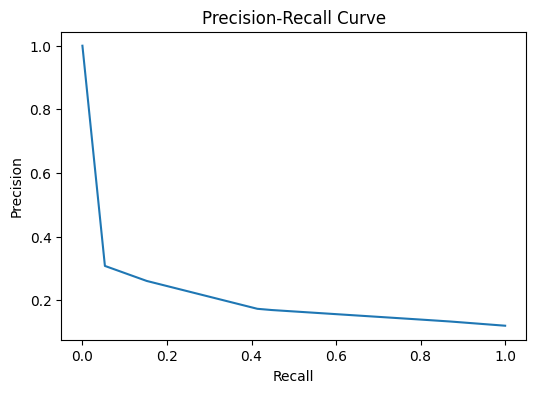

In [18]:
y_prob = pipe.predict_proba(X_test)[:,1]
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob, pos_label='yes')

plt.figure(figsize=(6,4))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [19]:
f1_scores = 2 * (precision * recall) / (precision + recall)

best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]

print("Best Threshold:", best_threshold)
print("Best F1 Score:", f1_scores[best_index])

Best Threshold: 0.5030278976862415
Best F1 Score: 0.24544349939246657


In [20]:
y_pred = np.where(y_prob > best_threshold, 'yes', 'no')
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          no       0.90      0.73      0.81      9950
         yes       0.17      0.41      0.24      1353

    accuracy                           0.69     11303
   macro avg       0.54      0.57      0.53     11303
weighted avg       0.81      0.69      0.74     11303



In [42]:
params ={
    'log_trf__solver':['lbfgs','liblinear','saga','newton-cg'],
    'log_trf__penalty':['l2','l1','elasticnet'],
    'log_trf__max_iter':[100,500,1000],
    'log_trf__C':[0.001,0.01,0.1,10],
}

In [45]:
from sklearn.model_selection import RandomizedSearchCV
random = RandomizedSearchCV(
    estimator=pipe,param_distributions=params,n_iter=10,cv=5,n_jobs=-1,random_state=42
)
random.fit(X_train,y_train)

d:\Bank-Marketing-Term-Predict\venv\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
15 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "d:\Bank-Marketing-Term-Predict\venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "d:\Bank-Marketing-Term-Predict\venv\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\Bank-Marketing-Term-Predict\venv\Lib\site-packages\sklearn\pipeline.py", lin

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...'balanced'))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'log_trf__C': [0.001, 0.01, ...], 'log_trf__max_iter': [100, 500, ...], 'log_trf__penalty': ['l2', 'l1', ...], 'log_trf__solver': ['lbfgs', 'liblinear', ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies

In [47]:
random.best_params_

{'log_trf__solver': 'saga',
 'log_trf__penalty': 'l1',
 'log_trf__max_iter': 500,
 'log_trf__C': 0.001}

In [85]:
import pickle
pickle.dump(pipe,open('pipe.pkl','wb'))

### Decision Tree Classifier

In [26]:
dt_trf=DecisionTreeClassifier(random_state=42)
pipe = Pipeline([
    ('trf1',transformer), #encoding
    ('trf2',scaler),  #feature scaling
    ('smote',SMOTE(random_state=42)), # handle class imbalance
    ('dt_trf',dt_trf) # model
    ])

In [27]:
pipe.fit(X_train,y_train)
y_pred_dt = pipe.predict(X_test)
print(classification_report(y_test,y_pred_dt))

              precision    recall  f1-score   support

          no       0.91      0.56      0.69      9950
         yes       0.15      0.59      0.24      1353

    accuracy                           0.56     11303
   macro avg       0.53      0.58      0.47     11303
weighted avg       0.82      0.56      0.64     11303



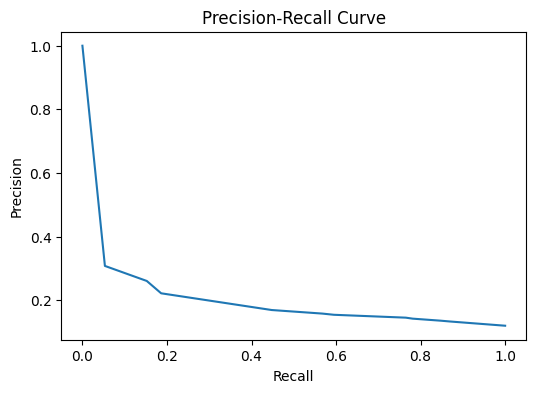

In [35]:
y_prob = pipe.predict_proba(X_test)[:,1]
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob, pos_label='yes')

plt.figure(figsize=(6,4))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

### Random Forest Classifier

In [36]:
rf_trf=RandomForestClassifier(random_state=42)
pipe_rf = Pipeline([
    ('trf1',transformer), #encoding
    ('trf2',scaler),  #feature scaling
    ('smote',SMOTE(random_state=42)), # handle class imbalance
    ('rf_trf',rf_trf) # model
    ])
pipe_rf.fit(X_train,y_train)
y_pred_rf = pipe_rf.predict(X_test)
print(classification_report(y_test,y_pred_rf))

d:\Bank-Marketing-Term-Predict\venv\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


              precision    recall  f1-score   support

          no       0.91      0.56      0.69      9950
         yes       0.15      0.59      0.24      1353

    accuracy                           0.56     11303
   macro avg       0.53      0.58      0.47     11303
weighted avg       0.82      0.56      0.64     11303



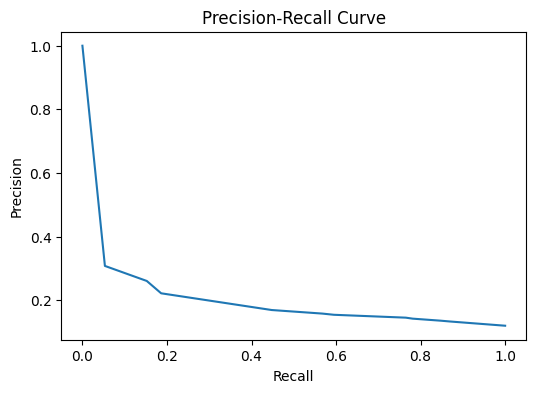

In [38]:
y_prob = pipe_rf.predict_proba(X_test)[:,1]
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob, pos_label='yes')

plt.figure(figsize=(6,4))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [39]:
import joblib
joblib.dump(pipe_rf,'rf_model.pkl')

['rf_model.pkl']

## Feature Engineering (for Improving Precision & Recall)
- Since the Random Forest model achieved high recall for the minority class but suffered from extremely low precision, meaning many non-subscribers were incorrectly predicted as subscribers. The Precision-Recall curve also showed a steep decline in precision as recall increased, indicating weak class separation.
- So this says that even ensemble models such as Random Forest also cannot handle the non-linearity in the dataset
- Even the Imbalanced Data problem is not solved by SMOTE and Hyperparameter Tuning